In [1]:
import gsw
import numpy as np
import xarray as xr 
from glob import glob
import glidertools as gt
import matplotlib.pyplot as plt

In [18]:
! cat /home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/sc0075a/ad2cp.dat 

% instrument: ad2cp ad2cp
% columns: elapsed_t(1,0) pressure(1000,0) temperature(100,0) heading(100,0) pitch(100,0) roll(100,0) battery(1,0) 
% container: sc0075a
% comment: SG267
% start: 2 22 126 6 49 55 386

�
�^�9$GETCLOCKSTR,TIME="2026-02-22 06:50:09"
ID,STR="Glider",SN=105521
GETHW,FW=2215,FPGA=186,DIGITAL="I-6",INTERFACE="J-1",ANALOG="G-1",SENSOR="I-0",BOOT=25,FWMINOR=15
BOARDSENSGET,AV=23,NB=4,HF=1000,TTR=2.0000,TTRB5=2.0000,TTRB5AUX=0.0000,AUXRS=0
GETPWR,PLAN=-nan,BURST=-nan,AVG=1594.08,PLAN1=0.00,BURST1=0.00,AVG1=0.00,TOTAL=-nan
GETMEM,PLAN=-nan,BURST=-nan,AVG=0.913,PLAN1=0.000,BURST1=0.000,AVG1=0.000,TOTAL=-nan
GETPRECISION,AVGHORZ=0.86,BURSTHORZ=-9.99,BEAM5=-9.99,AVGBEAM=0.51,BURSTBEAM=-9.99
GETPLAN,MIAVG=1,AVG=1,DIAVG=0,VD=0,MV=10,SA=35.0,BURST=0,MIBURST=0,DIBURST=0,SV=0.00,FN="",SO=1,FREQ=1000,NSTT=0
GETAVG,NC=15,CS=2.00,BD=0.10,CY="BEAM",PL=0.0,AI=1,VP=0.000,VR=2.50,DF=3,NPING=4,NB=3,CH=124,MUX=0,BW="BROAD",ALTI=0,BT=0,ICE=0,ALTISTART=0.10,ALTIEND=30.00,RAWALTI=0
GET

In [20]:
! cat /home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/sc0075a/psc2670075a_ad2cp_ad2cp.eng

              	   blanking       $@              	   cellSize      @�@                 soundspeed     �l�@                  velX                   velY                   velZ                	   pressure                  battery                   temperature                  heading                   pitch                   roll                   time 

In [22]:
from scipy.io import loadmat

fn = "/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/sc0075a/psc2670075a_ad2cp_ad2cp.mat"
mat = loadmat(fn, squeeze_me=True, struct_as_record=False)
mat

{'blanking': 10.0,
 'cellSize': 2000.0,
 'soundspeed': 15065.0,
 'velX': array([], dtype=float64),
 'velY': array([], dtype=float64),
 'velZ': array([], dtype=float64),
 'pressure': array([], dtype=float64),
 'battery': array([], dtype=float64),
 'temperature': array([], dtype=float64),
 'heading': array([], dtype=float64),
 'pitch': array([], dtype=float64),
 'roll': array([], dtype=float64),
 'time': array([], dtype=float64)}

In [ ]:
# check adcp data

ds = xr.open_dataset('/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670234.nc')

/tmp/ipykernel_1283020/354135034.py:3: FutureWarning: In a future version, xarray will not decode the variable 'sg_cal_sbect_tau_T' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset('/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670234.nc')
/tmp/ipykernel_1283020/354135034.py:3: FutureWarning: In a future version, xarray will not decode the variable 'gc_vbd_secs' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, w

In [ ]:
filenames = sorted(glob('/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/*.nc'))

lat_first_fix = np.array([])
lon_first_fix = np.array([])
lat_final_fix = np.array([])
lon_final_fix = np.array([])

for fname in filenames:

    ds = xr.open_dataset(fname, decode_timedelta=False)
    
    lat_first_fix = np.append(lat_first_fix, ds['log_gps_lat'][0].data)
    lon_first_fix = np.append(lon_first_fix, ds['log_gps_lon'][0].data)

    lat_final_fix = np.append(lat_final_fix, ds['log_gps_lat'][-1].data)
    lon_final_fix = np.append(lon_final_fix, ds['log_gps_lon'][-1].data)

array([[ 898.98586975,  772.36852581, 1048.36226051,  421.82583191,
         128.68965967,   46.05013657,   65.2157026 ,  193.8305652 ,
          44.08574074,  191.47096264,  268.01377849,  315.91885481,
         259.48782677,  280.19883058,  525.83423847,  300.58959311,
         356.90389023,  191.47609375,  296.88425952,  335.7289676 ,
         227.30088755,  432.79869548,  313.57860833,  312.51068273,
         333.43272074,  281.07974757,  283.37176504,  373.12459226,
         127.13047304,   77.00509461,   75.43490442,   60.43632513,
          78.41720863,  112.57532136,  124.25668587,  138.52135994,
          91.20341166,  206.93073404,  194.47128989,  232.79678654,
         140.43810086,  325.29922393,  316.99319457,  313.04732035,
         275.73872392,  139.82572449,  253.57106306,  313.71394388,
         292.64018532,  298.64727833,  357.65805742,  369.35415185,
         375.69195977,  377.83717546,  411.78692322,  446.05436875,
         504.81809357,  528.14757288,  515.42807

In [2]:
# load seaglider sg267 data

filenames = sorted(glob('/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/*.nc'))

# gt.load.seaglider_show_variables(filenames)

for fname in filenames:
    print(fname)

/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670001.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670002.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670003.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670004.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670005.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670006.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670007.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670008.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670009.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670010.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670011.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670012.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670013.nc
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670014.nc
/home/databot/share/www/data/sg267_WHIRLS_Missio

In [14]:
# names = [
#     'log_gps_lat',
#     'log_gps_lon',
#     'log_gps_first_fix_time',
#     'log_gps_final_fix_time'
# ]

# ds_dict = gt.load.seaglider_basestation_netCDFs(
#     filenames, names,
#     return_merged=False,
#     keep_global_attrs=False
# )

In [2]:
# load seaglider sg267 data

filenames = '/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/*.nc'

gt.load.seaglider_show_variables(filenames)

names = [
    'ctd_depth',
    'ctd_time',
    'ctd_pressure',
    'absolute_salinity',
    'conservative_temperature',
    'wlbb2fl_sig695nm_adjusted',
    'aanderaa4831_dissolved_oxygen',
    'gps_log_lat',
    'gps_log_lon'
]

ds_dict = gt.load.seaglider_basestation_netCDFs(
    filenames, names,
    return_merged=False,
    keep_global_attrs=False
)


information is based on file: /home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670118.nc


/home/databot/sw/miniconda3/envs/gliders/lib/python3.11/site-packages/glidertools/load/seaglider.py:224: GliderToolsWarning: gps_log_lat was not found in the files
  warnings.warn(msg, GliderToolsWarning)
/home/databot/sw/miniconda3/envs/gliders/lib/python3.11/site-packages/glidertools/load/seaglider.py:224: GliderToolsWarning: gps_log_lon was not found in the files
  warnings.warn(msg, GliderToolsWarning)



DIMENSION: ctd_data_point
{latitude, ctd_time, ctd_depth, longitude, ctd_pressure, absolute_salinity, conservative_temperature}


100%|██████████| 234/234 [00:12<00:00, 18.63it/s]



DIMENSION: wlbb2fl_data_point
{np.str_(wlbb2fl_results_time), wlbb2fl_sig695nm_adjusted}


100%|██████████| 234/234 [00:11<00:00, 19.57it/s]


/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670015.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670016.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670017.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670018.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670019.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670020.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670021.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670022.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670023.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670024.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670025.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670026.nc was skipped
/home/databot/share/www/data/sg267_WHIRL

100%|██████████| 234/234 [00:11<00:00, 20.03it/s]
/home/databot/sw/miniconda3/envs/gliders/lib/python3.11/site-packages/glidertools/load/seaglider.py:536: FutureWarning: In a future version, xarray will not decode the variable 'sg_cal_sbect_tau_T' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  first = list(open_dataset(files[0]).attrs.items())


/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670015.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670016.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670017.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670018.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670019.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670020.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670021.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670022.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670023.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670024.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670025.nc was skipped
/home/databot/share/www/data/sg267_WHIRLS_Mission2_2026/p2670026.nc was skipped
/home/databot/share/www/data/sg267_WHIRL

/home/databot/sw/miniconda3/envs/gliders/lib/python3.11/site-packages/glidertools/load/seaglider.py:536: FutureWarning: In a future version, xarray will not decode the variable 'gc_vbd_secs' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  first = list(open_dataset(files[0]).attrs.items())
/home/databot/sw/miniconda3/envs/gliders/lib/python3.11/site-packages/glidertools/load/seaglider.py:536: FutureWarning: In a future version, xarray will not decode the variable 'gc_pitch_secs' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute 

In [3]:
sg267_ctd = ds_dict['ctd_data_point']
sg267_chl = ds_dict['wlbb2fl_data_point']
sg267_oxy = ds_dict['aa4831_data_point']

In [5]:
sg267_oxy

<xarray.Dataset> Size: 4MB
Dimensions:                         (aa4831_data_point: 139225)
Dimensions without coordinates: aa4831_data_point
Data variables:
    aanderaa4831_results_time       (aa4831_data_point) float64 1MB 1.772e+09...
    aanderaa4831_dissolved_oxygen   (aa4831_data_point) float64 1MB 371.5 ......
    dives                           (aa4831_data_point) int64 1MB 1 1 ... 234
    aanderaa4831_results_time_dt64  (aa4831_data_point) datetime64[ns] 1MB 20...
Attributes:
    date_created:             2026-03-05 21:48:52
    number_of_dives:          234
    files:                    ['p2670001.nc', 'p2670002.nc', 'p2670003.nc', '...
    time_coverage_start:      2026-02-20 08:37:50
    time_coverage_end:        2026-03-05 16:37:02
    geospatial_vertical_min:  nan
    geospatial_vertical_max:  nan
    geospatial_lat_min:       nan
    geospatial_lat_max:       nan
    geospatial_lon_min:       nan
    geospatial_lon_max:       nan
    processing:               [2026-03-05 21:48:52] imported data with Glider...

In [6]:
import xarray as xr

ds_ctd  = ds_dict['ctd_data_point']
ds_chl  = ds_dict['wlbb2fl_data_point']
ds_oxy  = ds_dict['aa4831_data_point']

# if needed, rename to common coordinate names first:
ds_ctd = ds_ctd.rename({'ctd_time_dt64': 'time'})
ds_chl = ds_chl.rename({'wlbb2fl_results_time_dt64': 'time'})
ds_oxy = ds_oxy.rename({'aanderaa4831_results_time_dt64': 'time'})

ds_ctd_a, ds_chl_a, ds_oxy_a = xr.align(
    ds_ctd, ds_chl, ds_oxy, join='outer'
)

ds_all = xr.merge([ds_ctd_a, ds_chl_a, ds_oxy_a])


MergeError: conflicting values for variable 'dives' on objects to be combined. You can skip this check by specifying compat='override'.

In [28]:
import xarray as xr
import numpy as np

def split_dives_at_max_depth(ds, dive_coord='dives',
                             depth_var='ctd_depth',
                             time_dim='time',
                             new_name='dives_split'):
    """
    Split each Seaglider dive into downcast and upcast using the
    deepest sample as the turning point.

    For each original dive number d:
      - samples up to and including max depth get label d
      - samples after max depth get label d + 0.5

    Returns a new Dataset with an added coordinate `new_name`.
    """
    dives = ds[dive_coord]
    depth = ds[depth_var]
    time  = ds[time_dim]

    new_dive = xr.full_like(dives, np.nan, dtype=float)

    for d in np.unique(dives.values):
        mask_d = (dives == d)
        if not mask_d.any():
            continue

        # depth/time for this dive only
        depth_d = depth.where(mask_d, drop=True)
        time_d  = time.where(mask_d, drop=True)

        # index of deepest sample in this dive
        i_turn = int(depth_d.argmax(time_dim))
        t_turn = time_d.isel({time_dim: i_turn})

        # downcast: <= deepest point
        down_mask = mask_d & (time <= t_turn)
        # upcast: > deepest point
        up_mask   = mask_d & (time > t_turn)

        new_dive = xr.where(down_mask, float(d), new_dive)
        new_dive = xr.where(up_mask,  float(d) + 0.5, new_dive)

    return ds.assign_coords({new_name: (dives.dims, new_dive)})


In [ ]:
import xarray as xr

ds_ctd    = ds_dict['ctd_data_point']
ds_wlbb2  = ds_dict['wlbb2fl_data_point']
ds_aa4831 = ds_dict['aa4831_data_point']

# Align to a common time axis (interpolating/NaN‑filling as needed)
ds_ctd_a, ds_wlbb2_a, ds_aa4831_a = xr.align(
    ds_ctd, ds_wlbb2, ds_aa4831, join='outer'
)

# Merge into a single Dataset
ds_all = xr.merge([ds_ctd_a, ds_wlbb2_a, ds_aa4831_a])


In [29]:
aa = ds_dict['aa4831_data_point']
aa = split_dives_at_max_depth(
    aa,
    dive_coord='dives',
    depth_var='ctd_depth',
    time_dim='time',
    new_name='dives_split'
)


KeyError: "No variable named 'ctd_depth'. Variables on the dataset include ['aanderaa4831_dissolved_oxygen', 'aa4831_time', 'dives', 'aa4831_time_dt64']"

In [8]:
import cmocean.cm as cmo

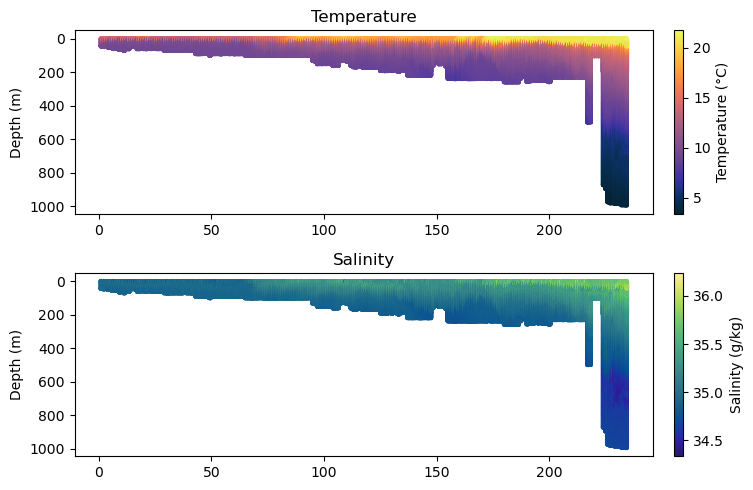

In [18]:
fig,ax=plt.subplots(2,1,figsize=(8,5))

img0=ax[0].scatter(sg267_ctd['dives'],sg267_ctd['ctd_depth'],5,sg267_ctd['conservative_temperature'], cmap=cmo.thermal)
img1=ax[1].scatter(sg267_ctd['dives'],sg267_ctd['ctd_depth'],5,sg267_ctd['absolute_salinity'], cmap=cmo.haline)

ax[0].set_title('Temperature')
ax[1].set_title('Salinity')

plt.colorbar(img0,ax=ax[0],label='Temperature (°C)', pad=0.03)
plt.colorbar(img1,ax=ax[1],label='Salinity (g/kg)', pad=0.03)

for a in ax:
    a.invert_yaxis()
    a.set_ylabel('Depth (m)')

fig.tight_layout()

ValueError: Do not know how to convert 'none' to dashes

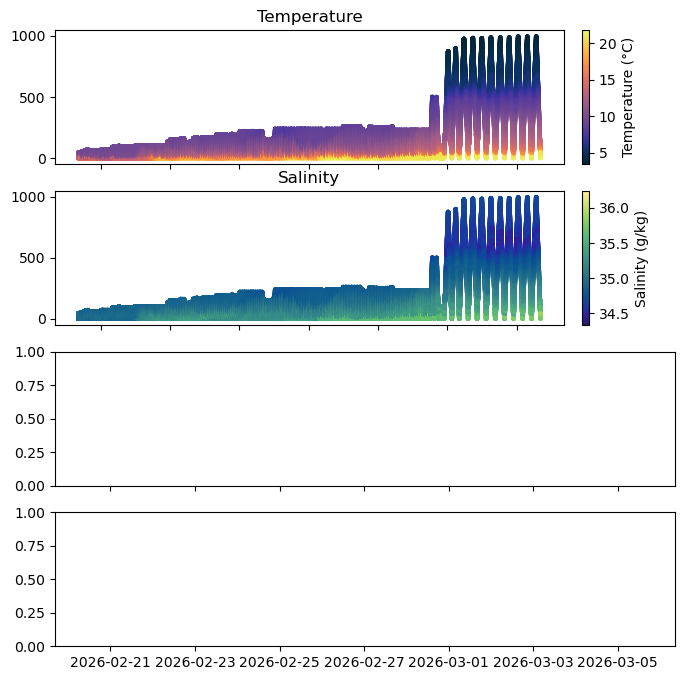

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# Main plots
img0 = ax[0].scatter(
    sg267_ctd['dives'], sg267_ctd['ctd_depth'], 5,
    sg267_ctd['conservative_temperature'], cmap=cmo.thermal
)
img1 = ax[1].scatter(
    sg267_ctd['dives'], sg267_ctd['ctd_depth'], 5,
    sg267_ctd['absolute_salinity'], cmap=cmo.haline
)

ax[0].set_title('Temperature')
ax[1].set_title('Salinity')

plt.colorbar(img0, ax=ax[0], label='Temperature (°C)', pad=0.03)
plt.colorbar(img1, ax=ax[1], label='Salinity (g/kg)', pad=0.03)

# New subplots
ax[2].scatter(
    sg267_chl['dives'], sg267_chl['wlbb2fl_sig695nm_adjusted'], 5
)
ax[2].set_title('wlbb2fl data point')

ax[3].scatter(
    sg267_oxy['aa4831_time_dt64'], sg267_oxy['aanderaa4831_dissolved_oxygen'],
    marker='.', linestyle='none'
)
ax[3].set_title('aa4831 data point')

# Common formatting
start = sg267_ctd['ctd_time_dt64'].min()
end   = sg267_ctd['ctd_time_dt64'].max()
for a in ax:
    if a in ax[:2]:
        a.invert_yaxis()
        a.set_ylabel('Depth (m)')
    a.tick_params(direction='out')          # ticks outwards
    a.spines['top'].set_visible(False)      # remove top axis line
    a.set_xlim(start, end)                  # xlim to data range

# Date formatting
locator = mdates.AutoDateLocator()
formatter = mdates.DateFormatter('%b %d')   # e.g. 'Mar 06'
ax[-1].xaxis.set_major_locator(locator)
ax[-1].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

fig.tight_layout()
